
## ANALYSIS PLAN
- Revenue metrics and trend analysis
- Customer segmentation (RFM and ML clustering)
- Cohort analysis and retention tracking
- Purchase behavior analysis
- Sales forecasting
- Data quality assessment
- Strategic business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy import stats


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [28]:
df = pd.read_csv('online_retail.csv', encoding='latin1')


print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Values'] > 0])
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print("\nDescriptive Statistics:")
print(df.describe())


Dataset Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
             Missing Values  Percentage
Description            1454        0.27
CustomerID           135080       24.93

Duplicate Rows: 5268

Descriptive Statistics:
       Quantity  UnitPrice  CustomerID
count 541909.00  541909.00   406829.00
mean       9.55       4.61    15287.69
std      218.08      96.76     1713.60
min   -80995.00  -11062.06    12346.00
25%        1.00       1.25    13953.00
50%        3.00       2.08    15152.00
75%       10.00       4.13    16791.00
max    80995.00   38970.00    18287.00


In [29]:
initial_rows = len(df)
df = df.dropna(subset=['CustomerID'])
print(f"Removed {initial_rows - len(df)} rows with missing CustomerID")

initial_rows = len(df)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f"Removed {initial_rows - len(df)} rows with negative quantities or prices")

initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows")

df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month_Year'] = df['InvoiceDate'].dt.to_period('M')
df['Date'] = df['InvoiceDate'].dt.date
df['Date'] = pd.to_datetime(df['Date'])

print(f"\nFinal dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique customers: {df['CustomerID'].nunique()}")
print(f"Total revenue: ${df['Revenue'].sum():,.2f}")

Removed 135080 rows with missing CustomerID
Removed 8945 rows with negative quantities or prices
Removed 5192 duplicate rows

Final dataset shape: (392692, 17)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Unique customers: 4338
Total revenue: $8,887,208.89


In [11]:
def analyze_revenue_metrics(df):
    """
    Calculate metrics
    """
    total_revenue = df['Revenue'].sum()
    total_transactions = df['InvoiceNo'].nunique()
    unique_customers = df['CustomerID'].nunique()
    avg_order_value = total_revenue / total_transactions
    revenue_per_customer = total_revenue / unique_customers
    avg_items_per_transaction = df.groupby('InvoiceNo')['Quantity'].sum().mean()
    print(f"Total Revenue: ${total_revenue:,.2f}")
    print(f"Total Transactions: {total_transactions:,}")
    print(f"Unique Customers: {unique_customers:,}")
    print(f"Average Order Value (AOV): ${avg_order_value:.2f}")
    print(f"Revenue per Customer: ${revenue_per_customer:.2f}")
    print(f"Average Items per Transaction: {avg_items_per_transaction:.1f}")


    daily_revenue = df.groupby('Date').agg({
        'Revenue': 'sum',
        'InvoiceNo': 'nunique',
        'CustomerID': 'nunique'
    }).round(2)
    daily_revenue.columns = ['Revenue', 'Transactions', 'UniqueCustomers']
    daily_revenue['AOV'] = daily_revenue['Revenue'] / daily_revenue['Transactions']

    monthly_revenue = df.groupby('Month_Year').agg({
        'Revenue': 'sum',
        'InvoiceNo': 'nunique',
        'CustomerID': 'nunique'
    }).round(2)
    monthly_revenue.columns = ['Revenue', 'Transactions', 'UniqueCustomers']
    monthly_revenue['AOV'] = monthly_revenue['Revenue'] / monthly_revenue['Transactions']


    country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))


    axes[0, 0].plot(daily_revenue.index, daily_revenue['Revenue'],
                    color='blue', alpha=0.7, linewidth=1)
    axes[0, 0].set_title('Daily Revenue Trend', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Revenue ($)')
    axes[0, 0].tick_params(axis='x', rotation=45)


    monthly_revenue['Revenue'].plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
    axes[0, 1].set_title('Monthly Revenue', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Revenue ($)')
    axes[0, 1].tick_params(axis='x', rotation=45)


    country_revenue.plot(kind='bar', ax=axes[1, 0], color='orange', alpha=0.7)
    axes[1, 0].set_title('Top 10 Countries by Revenue', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Country')
    axes[1, 0].set_ylabel('Revenue ($)')
    axes[1, 0].tick_params(axis='x', rotation=45)


    axes[1, 1].plot(daily_revenue.index, daily_revenue['AOV'],
                    color='red', alpha=0.7, linewidth=1)
    axes[1, 1].set_title('Average Order Value Trend', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('AOV ($)')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('revenue_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    return daily_revenue, monthly_revenue, country_revenue

Total Revenue: $8,887,208.89
Total Transactions: 18,532
Unique Customers: 4,338
Average Order Value (AOV): $479.56
Revenue per Customer: $2048.69
Average Items per Transaction: 278.0


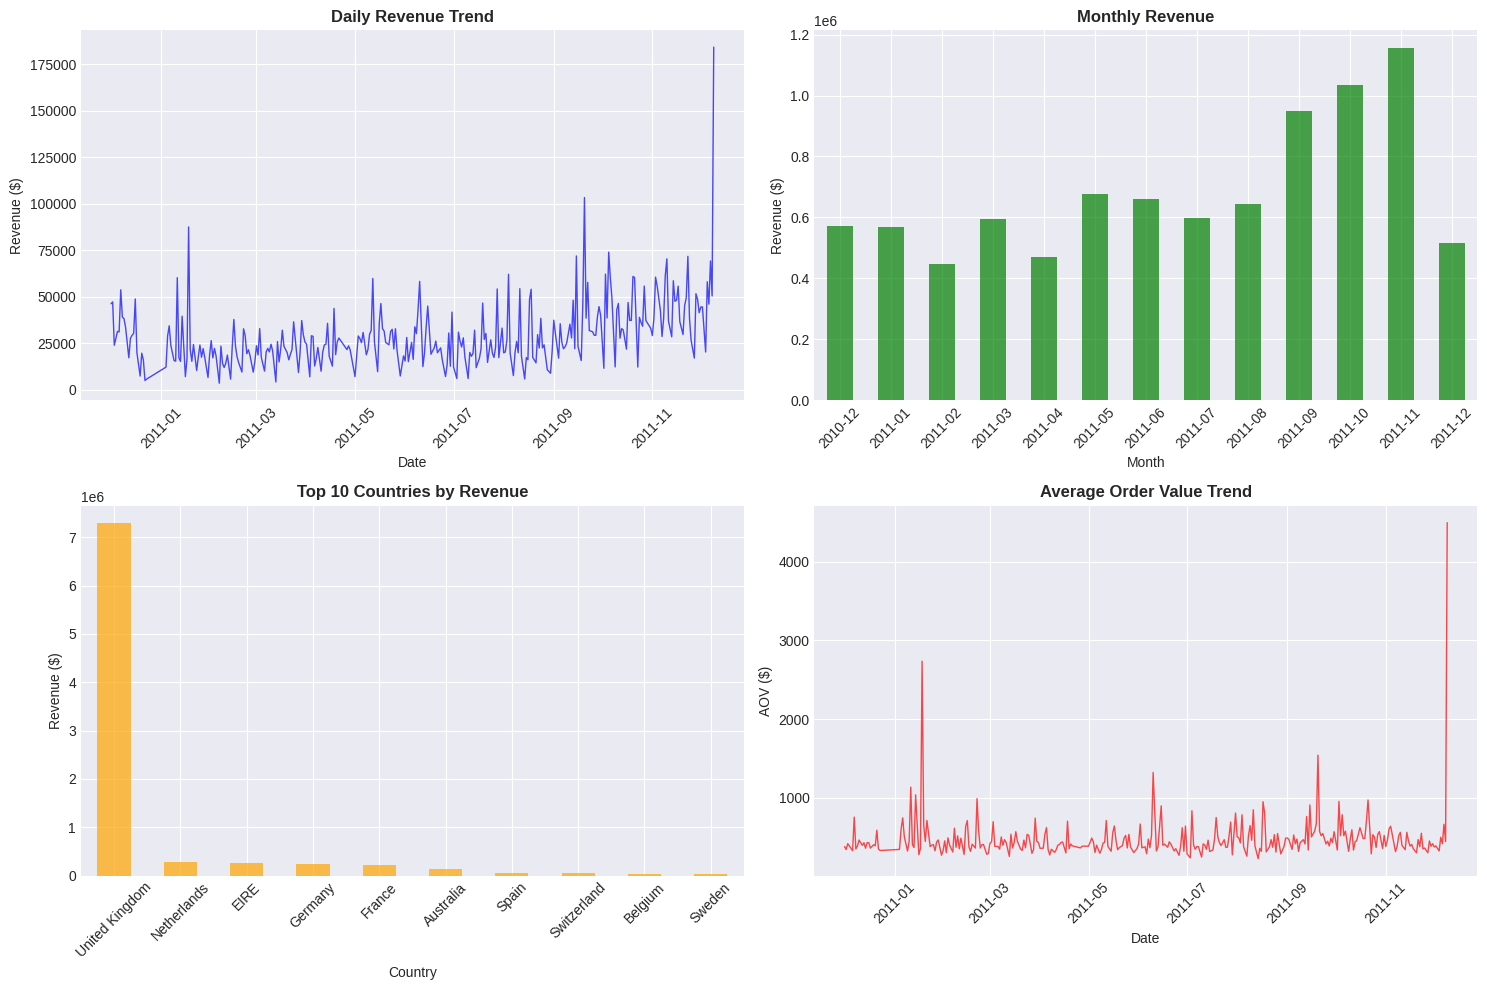

In [12]:
daily_rev, monthly_rev, country_rev = analyze_revenue_metrics(df)

Customer Types by Purchase Frequency:
One-time: 1493 customers (34.4%)
Regular: 1138 customers (26.2%)
Frequent: 872 customers (20.1%)
Occasional: 835 customers (19.2%)

Revenue Contribution by Customer Type:
One-time: $613,989.56 (6.9%)
Occasional: $737,463.75 (8.3%)
Regular: $1,641,761.57 (18.5%)
Frequent: $5,893,994.01 (66.3%)


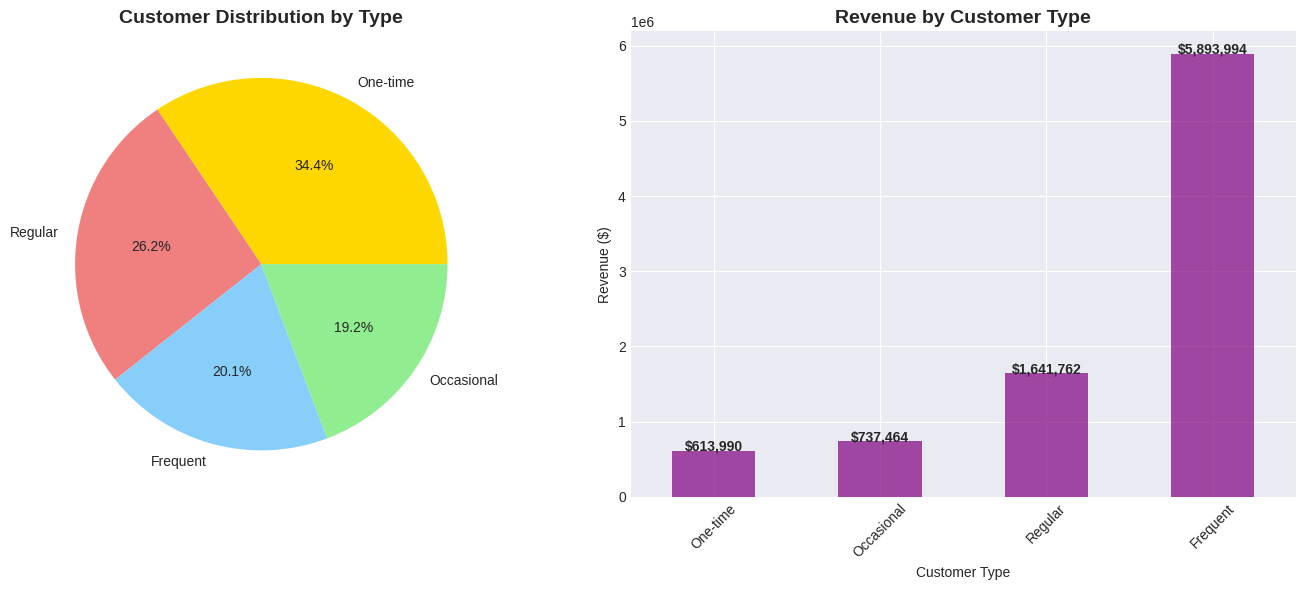

In [36]:
customer_metrics = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Revenue': 'sum',
    'Quantity': 'sum',
    'Date': ['min', 'max']
}).round(2)

customer_metrics.columns = ['TotalTransactions', 'TotalRevenue', 'TotalItems', 'FirstPurchase', 'LastPurchase']
customer_metrics = customer_metrics.reset_index()

customer_metrics['CustomerType'] = pd.cut(customer_metrics['TotalTransactions'],
                                          bins=[0, 1, 2, 5, float('inf')],
                                          labels=['One-time', 'Occasional', 'Regular', 'Frequent'])

customer_type_dist = customer_metrics['CustomerType'].value_counts()
customer_type_pct = (customer_type_dist / len(customer_metrics) * 100).round(1)

print("Customer Types by Purchase Frequency:")
for cust_type in customer_type_dist.index:
    print(f"{cust_type}: {customer_type_dist[cust_type]} customers ({customer_type_pct[cust_type]}%)")

revenue_by_type = customer_metrics.groupby('CustomerType')['TotalRevenue'].sum()
revenue_pct = (revenue_by_type / revenue_by_type.sum() * 100).round(1)

print("\nRevenue Contribution by Customer Type:")
for cust_type in revenue_by_type.index:
    print(f"{cust_type}: ${revenue_by_type[cust_type]:,.2f} ({revenue_pct[cust_type]}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(customer_type_dist.values, labels=customer_type_dist.index, autopct='%1.1f%%',
            colors=['gold', 'lightcoral', 'lightskyblue', 'lightgreen'])
axes[0].set_title('Customer Distribution by Type', fontsize=14, fontweight='bold')

revenue_by_type.plot(kind='bar', ax=axes[1], color='purple', alpha=0.7)
axes[1].set_title('Revenue by Customer Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(revenue_by_type.values):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('customer_types.png', dpi=300, bbox_inches='tight')
plt.show()

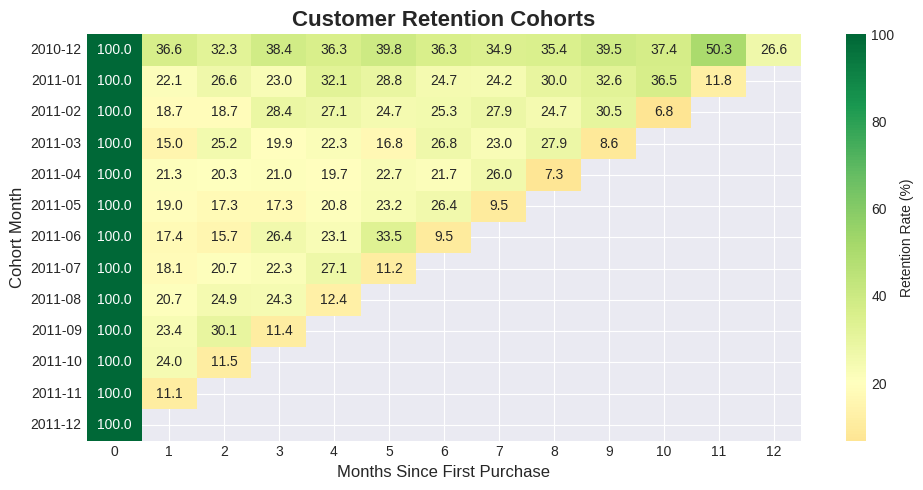

In [37]:
customer_first = df.groupby('CustomerID')['Date'].min().reset_index()
customer_first.columns = ['CustomerID', 'FirstPurchase']
customer_first['CohortMonth'] = customer_first['FirstPurchase'].dt.to_period('M')

df_cohort = df.merge(customer_first[['CustomerID', 'CohortMonth']], on='CustomerID')

df_cohort['TransactionMonth'] = df_cohort['Date'].dt.to_period('M')
df_cohort['CohortIndex'] = (df_cohort['TransactionMonth'] - df_cohort['CohortMonth']).apply(lambda x: x.n)

cohort_counts = df_cohort.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot_table(index='CohortMonth',
                                         columns='CohortIndex',
                                         values='CustomerID')

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(10, 5))

retention_matrix_display = retention_matrix.copy()
retention_matrix_display.index = retention_matrix_display.index.astype(str)

sns.heatmap(retention_matrix_display,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=20,
            cbar_kws={'label': 'Retention Rate (%)'})

plt.title('Customer Retention Cohorts', fontsize=16, fontweight='bold')
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.savefig('cohort_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
avg_retention = retention_matrix.mean()
print("Average Retention by Month:")
for month, rate in avg_retention.items():
    if month > 0:
        print(f"Month {month}: {rate:.1f}%")

Average Retention by Month:
Month 1: 20.6%
Month 2: 22.1%
Month 3: 23.2%
Month 4: 24.6%
Month 5: 25.1%
Month 6: 24.4%
Month 7: 24.3%
Month 8: 25.1%
Month 9: 27.8%
Month 10: 26.9%
Month 11: 31.0%
Month 12: 26.6%


In [39]:
reference_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Statistics:")
print(rfm.describe())

rfm = rfm[rfm['Monetary'] > 0]
rfm = rfm[rfm['Frequency'] > 0]

RFM Statistics:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     93.06       4.27   2048.69
std     100.01       7.70   8985.23
min       1.00       1.00      3.75
25%      18.00       1.00    306.48
50%      51.00       2.00    668.57
75%     142.75       5.00   1660.60
max     374.00     209.00 280206.02


In [40]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

for col in ['R_Score', 'F_Score', 'M_Score']:
    rfm[col] = rfm[col].astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment_customers(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

segment_analysis = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean'
}).round(2)

segment_analysis['Percentage'] = (segment_analysis['CustomerID'] / len(rfm) * 100).round(1)
segment_analysis = segment_analysis.sort_values('Monetary', ascending=False)

print("\nCustomer Segments:")
print(segment_analysis)


Customer Segments:
                     CustomerID  Monetary  Frequency  Recency  Percentage
Segment                                                                  
Champions                   931   6697.46      11.77    15.09       21.50
Loyal Customers            1009   1387.85       3.87    43.86       23.30
Potential Loyalists        1088    814.57       2.01    86.20       25.10
At Risk                     765    341.34       1.23   147.59       17.60
Lost                        545    191.12       1.01   254.49       12.60


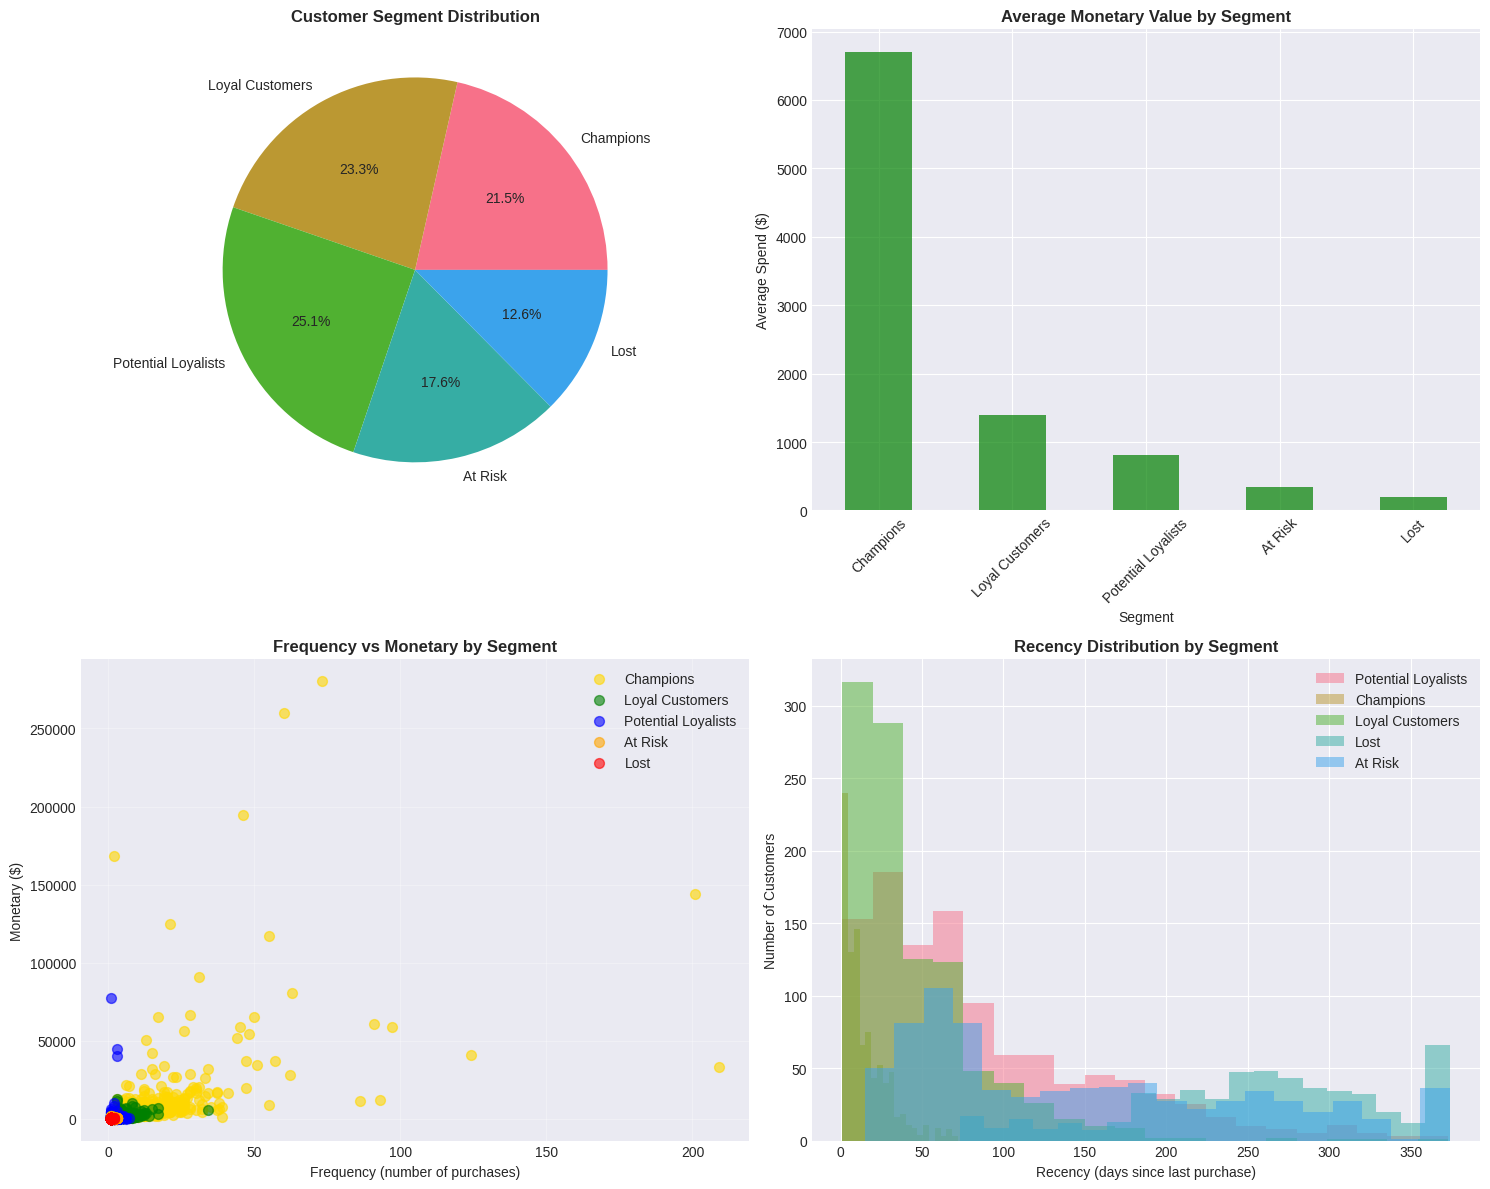

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

segment_analysis['CustomerID'].plot(kind='pie', ax=axes[0, 0], autopct='%1.1f%%')
axes[0, 0].set_title('Customer Segment Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('')

segment_analysis['Monetary'].plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
axes[0, 1].set_title('Average Monetary Value by Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Average Spend ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

colors = {'Champions': 'gold', 'Loyal Customers': 'green',
          'Potential Loyalists': 'blue', 'At Risk': 'orange', 'Lost': 'red'}

for segment, color in colors.items():
    if segment in rfm['Segment'].unique():
        segment_data = rfm[rfm['Segment'] == segment]
        axes[1, 0].scatter(segment_data['Frequency'], segment_data['Monetary'],
                          c=color, label=segment, alpha=0.6, s=50)

axes[1, 0].set_title('Frequency vs Monetary by Segment', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Frequency (number of purchases)')
axes[1, 0].set_ylabel('Monetary ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for segment in rfm['Segment'].unique():
    axes[1, 1].hist(rfm[rfm['Segment'] == segment]['Recency'],
                    alpha=0.5, label=segment, bins=20)

axes[1, 1].set_title('Recency Distribution by Segment', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Recency (days since last purchase)')
axes[1, 1].set_ylabel('Number of Customers')
axes[1, 1].legend()

plt.tight_layout()
# plt.savefig('rfm_segments.png', dpi=300, bbox_inches='tight')
plt.show()

## CUSTOMER SEGMENT STRATEGIES

### 1. CHAMPIONS
- Implement VIP loyalty program with exclusive benefits and early access
- Create referral program to acquire similar high-value customers
- Invite to product testing and feedback sessions
- Send personalized thank-you gifts on anniversary of first purchase

### 2. LOYAL CUSTOMERS
- Develop upsell and cross-sell campaigns based on purchase history
- Create product bundles at slightly discounted prices
- Send monthly engagement emails with personalized recommendations
- Offer loyalty points that can be redeemed for future purchases

### 3. POTENTIAL LOYALISTS
- Encourage second purchase with targeted 10-15% discounts
- Collect feedback to understand and improve their experience
- Showcase popular products and bestsellers in their preferred categories
- Send educational content about product features and benefits

### 4. AT RISK
- Launch win-back campaigns with special "We miss you" offers (20% off)
- Send personalized product recommendations based on past purchases
- Conduct surveys to understand reasons for reduced engagement
- Consider limited-time reactivation bonus

### 5. LOST
- Create re-engagement email series with strong incentives (25-30% off)
- Send "We've improved" messaging highlighting new products/features
- Consider one final reactivation attempt before archive
- Analyze common characteristics to prevent future churn

Data Split:
Training period: 2010-12-01 00:00:00 to 2011-09-29 00:00:00
Testing period: 2011-09-30 00:00:00 to 2011-12-09 00:00:00
Training samples: 244
Testing samples: 61
Forecast Accuracy Metrics:
MAE: $14188.89
RMSE: $17912.17
MAPE: 32.12%


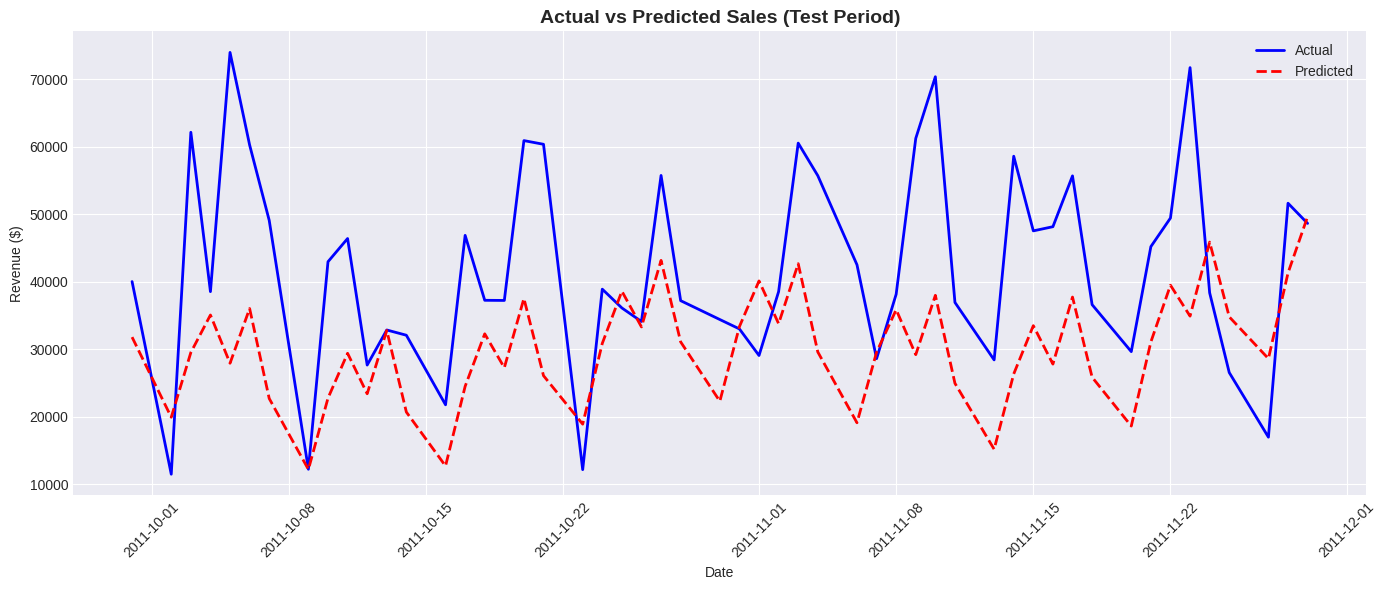

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

daily_sales = df.groupby('Date')['Revenue'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales = daily_sales.sort_values('ds')

train_size = int(len(daily_sales) * 0.8)
train = daily_sales[:train_size]
test = daily_sales[train_size:]

print(f"Data Split:")
print(f"Training period: {train['ds'].min()} to {train['ds'].max()}")
print(f"Testing period: {test['ds'].min()} to {test['ds'].max()}")
print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

model.fit(train)

future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

predictions = forecast[['ds', 'yhat']].tail(len(test))
predictions.columns = ['ds', 'predicted']

accuracy_df = test.merge(predictions, on='ds')

mae = mean_absolute_error(accuracy_df['y'], accuracy_df['predicted'])
mse = mean_squared_error(accuracy_df['y'], accuracy_df['predicted'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((accuracy_df['y'] - accuracy_df['predicted']) / accuracy_df['y'])) * 100

print(f"Forecast Accuracy Metrics:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(accuracy_df['ds'], accuracy_df['y'], 'b-', label='Actual', linewidth=2)
plt.plot(accuracy_df['ds'], accuracy_df['predicted'], 'r--', label='Predicted', linewidth=2)
plt.title('Actual vs Predicted Sales (Test Period)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=300, bbox_inches='tight')
plt.show()


Next 30 Days Forecast:
        ds     yhat  yhat_lower  yhat_upper
2011-09-30 31792.24    19013.06    45290.72
2011-10-01 37089.66    24249.59    50695.52
2011-10-02 19922.52     7161.28    33504.15
2011-10-03 29515.13    16111.48    42779.19
2011-10-04 35070.17    22711.61    47423.66
2011-10-05 27920.58    15399.03    40721.67
2011-10-06 36027.50    23751.40    49591.05
2011-10-07 22696.36     9566.35    35885.87
2011-10-08 28622.42    16437.39    41864.04
2011-10-09 12186.69    -1703.15    25040.17
...

Expected Revenue Next 30 Days: $866,013.30
Confidence Interval: $472,692.54 - $1,258,308.57


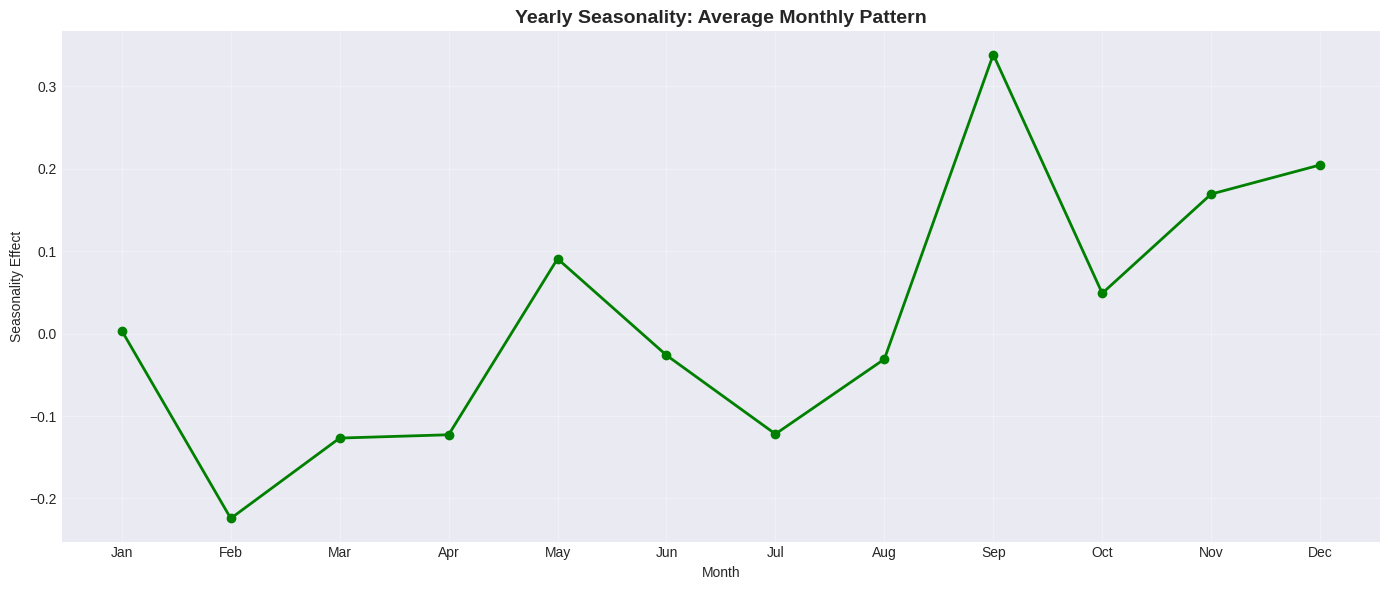

In [44]:
future_30 = model.make_future_dataframe(periods=30)
forecast_30 = model.predict(future_30)

future_predictions = forecast_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)

print("\nNext 30 Days Forecast:")
print(future_predictions.head(10).to_string(index=False))
print("...")

expected_revenue = future_predictions['yhat'].sum()
lower_bound = future_predictions['yhat_lower'].sum()
upper_bound = future_predictions['yhat_upper'].sum()

print(f"\nExpected Revenue Next 30 Days: ${expected_revenue:,.2f}")
print(f"Confidence Interval: ${lower_bound:,.2f} - ${upper_bound:,.2f}")

# Yearly seasonality by month
plt.figure(figsize=(14, 6))
yearly = forecast[['ds', 'yearly']].copy()
yearly['month'] = yearly['ds'].dt.month
monthly_avg = yearly.groupby('month')['yearly'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(monthly_avg['month'], monthly_avg['yearly'], 'g-', linewidth=2, marker='o')
plt.title('Yearly Seasonality: Average Monthly Pattern', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Seasonality Effect')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

forecast_model = model
forecast_results = forecast
accuracy = accuracy_df

In [35]:
total_revenue = df['Revenue'].sum()
total_customers = df['CustomerID'].nunique()
total_transactions = df['InvoiceNo'].nunique()
avg_revenue_per_customer = total_revenue / total_customers
avg_transactions_per_customer = total_transactions / total_customers

revenue_per_transaction = total_revenue / total_transactions
repeat_customers = len(customer_metrics[customer_metrics['TotalTransactions'] > 1])
repeat_rate = (repeat_customers / total_customers) * 100

top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)

df['Month'] = df['Date'].dt.to_period('M')
monthly_active = df.groupby('Month')['CustomerID'].nunique()
avg_monthly_active = monthly_active.mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Avg Revenue/Customer: ${avg_revenue_per_customer:,.2f}")
print(f"Avg Transactions/Customer: {avg_transactions_per_customer:.1f}")
print(f"Avg Revenue/Transaction: ${revenue_per_transaction:,.2f}")
print(f"Repeat Customer Rate: {repeat_rate:.1f}%")
print(f"Avg Monthly Active Customers: {avg_monthly_active:.0f}")

print("\nTop 5 Products by Revenue:")
for product, rev in top_products.items():
    short_product = product[:50] + "..." if len(product) > 50 else product
    print(f"  {short_product}: ${rev:,.2f}")

print("\nTop 5 Countries by Revenue:")
for country, rev in top_countries.items():
    pct = (rev / total_revenue) * 100
    print(f"  {country}: ${rev:,.2f} ({pct:.1f}%)")

Total Revenue: $8,887,208.89
Total Customers: 4,338
Total Transactions: 18,532
Avg Revenue/Customer: $2,048.69
Avg Transactions/Customer: 4.3
Avg Revenue/Transaction: $479.56
Repeat Customer Rate: 65.6%
Avg Monthly Active Customers: 1004

Top 5 Products by Revenue:
  PAPER CRAFT , LITTLE BIRDIE: $168,469.60
  REGENCY CAKESTAND 3 TIER: $142,264.75
  WHITE HANGING HEART T-LIGHT HOLDER: $100,392.10
  JUMBO BAG RED RETROSPOT: $85,040.54
  MEDIUM CERAMIC TOP STORAGE JAR: $81,416.73

Top 5 Countries by Revenue:
  United Kingdom: $7,285,024.64 (82.0%)
  Netherlands: $285,446.34 (3.2%)
  EIRE: $265,262.46 (3.0%)
  Germany: $228,678.40 (2.6%)
  France: $208,934.31 (2.4%)


## PRODUCT STRATEGY
- Focus marketing budget on top 5 products which generate significant revenue
- Bundle slow-moving items with bestsellers to clear inventory
- Consider seasonal promotions based on historical patterns identified in forecasting
- Analyze product return rates (if data available) to identify quality issues

## GEOGRAPHIC EXPANSION
- Strengthen presence in top countries
- Analyze shipping costs and delivery times for top international markets
- Consider local currency pricing for top non-UK countries
- Explore marketing partnerships in key markets
- Investigate high-growth potential in countries with increasing order volume

## MARKETING OPTIMIZATION
- Allocate 40% of marketing budget to Champions and Loyal Customers retention
- Allocate 30% to converting Potential Loyalists into Loyal Customers
- Allocate 20% to win-back campaigns for At Risk customers
- Allocate 10% to reactivation campaigns for Lost customers

## TIMING OPTIMIZATION
- Schedule email campaigns based on peak purchase hours identified in data
- Plan promotions around monthly active customer peaks
- Test different messaging for weekday vs weekend purchasers
- Prepare inventory for seasonal spikes identified in forecast

## EXPERIMENTS
1. Implement A/B testing for recommended discount levels
2. Test personalized product recommendations engine

## MONITORING RECOMMENDATIONS

**Weekly KPIs:**
- Revenue and transaction volume
- New customer acquisition
- Repeat purchase rate
- Segment size changes
- Forecast accuracy

**Monthly KPIs:**
- Cohort retention rates
- Customer lifetime value by cohort
- Average order value trends
- Customer acquisition cost (if data available)

## DATA QUALITY IMPROVEMENTS
- Implement consistent customer ID tracking across all touchpoints
- Collect additional customer attributes (age, gender, preferences)
- Track marketing source/channel for each customer
- Implement event tracking for website/app interactions
- Collect customer feedback and satisfaction scores